# Notebook 09 — Full Rerun with Multistart + Polarity Fix, then Ambiguity Review

## What this notebook does

**Part A — Full rerun:** Re-runs all 17 containers with the corrected `sparse_noise.py`:
- Multi-start LM (15 random initialisations per order) guards against local minima
- m=0 polarity fix: pre-flips OFF-dominant maps before fitting so A≥0 constraint never collapses
- ΔR² > 0.05 parsimonious threshold for order selection
- Results saved to `outputs/rf_params/nb09/` (new directory, does not overwrite nb05d)

**Part B — Ambiguity flagging:** After the rerun, flags every neuron meeting either criterion:
1. `max(r2_m0, r2_m1, r2_m2) − min(r2_m0, r2_m1, r2_m2) < 0.15` — models indistinguishable
2. `r_squared < 0.5` — best fit too weak to trust order assignment

**Part C — Manual review loop:** Iterates through flagged neurons with the same
two-cell (show / record) pattern as nb07. Judgements saved to a separate
`nb09_review_judgements.csv` so nb07 manual work is preserved.

**Part D — Merge:** Combines nb09 automated results with review judgements → final
`rf_params_nb09_final.csv` ready for parameter analysis.

## Why
After 231 neurons of manual inspection in nb07, the pattern is clear:
- When R² spread across orders is < 0.15 the correct classification is visual only
- When best R² < 0.5 the map is too noisy for reliable automated order assignment
- Both criteria identify exactly the cases that the multistart fix and polarity fix
  are most likely to have changed vs nb05d


In [1]:
import sys, warnings, time, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import RidgeCV, Ridge
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

sys.path.insert(0, os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study/src'))
from rf_analysis.sparse_noise import (
    classify_rf_order,
    fit_rf_by_order,
    _build_design_matrix,
    _pixel_size,
    _LAMBDA_GRID,
    gaussian_deriv_m0,
    gaussian_deriv_m1,
    gaussian_deriv_m2,
)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [2]:
# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
base_dir    = Path(os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study'))
cache_dir   = base_dir / 'data' / 'cache'
lists_dir   = base_dir / 'data' / 'experiment_lists'
outputs_dir = base_dir / 'outputs' / 'rf_params'
ridge_dir   = outputs_dir / 'ridge'          # nb05b cortex coords (read-only)
nb09_dir    = outputs_dir / 'nb09'           # all nb09 outputs go here
nb09_dir.mkdir(parents=True, exist_ok=True)

COMBINED_CSV    = nb09_dir / 'rf_params_nb09_all_containers.csv'
FLAGGED_CSV     = nb09_dir / 'rf_params_nb09_flagged.csv'
JUDGEMENT_CSV   = nb09_dir / 'nb09_review_judgements.csv'
FINAL_CSV       = nb09_dir / 'rf_params_nb09_final.csv'

manifest_path = str(cache_dir / 'manifest.json')
boc = BrainObservatoryCache(manifest_file=manifest_path)

batch_df  = pd.read_csv(lists_dir / 'all_l23_excitatory_experiments.csv')
verify_df = pd.read_csv(lists_dir / 'downloaded_all_l23_excitatory_experiments.csv')
downloaded    = set(verify_df[verify_df['exists']]['experiment_id'].tolist())
container_meta = pd.read_csv(lists_dir / 'container_neuron_counts.csv')
complete_ids   = set(container_meta['container_id'].tolist())

session_c = batch_df[
    batch_df['session_type'].str.contains('C') &
    batch_df['id'].isin(downloaded) &
    batch_df['experiment_container_id'].isin(complete_ids)
].copy()
container_to_exp = dict(zip(session_c['experiment_container_id'], session_c['id']))

print(f'Session C containers: {len(container_to_exp)}')
print(f'nb09 output dir: {nb09_dir}')

Session C containers: 17
nb09 output dir: /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/nb09


In [3]:
# ---------------------------------------------------------------------------
# batch_get_rf_maps_safe — identical to nb05d
# ---------------------------------------------------------------------------
def batch_get_rf_maps_safe(dataset, requested_ids,
                            n_lags=8, response_delay=4, response_window=5):
    exp_cells = list(dataset.get_cell_specimen_ids())
    req_set   = set(int(c) for c in requested_ids)
    valid_ids = [c for c in exp_cells if c in req_set]
    if not valid_ids:
        raise ValueError('No requested cell_ids found in experiment.')

    stim_name = next((s for s in dataset.list_stimuli() if 'sparse_noise' in s), None)
    if stim_name is None:
        raise ValueError('No sparse noise stimulus.')

    stim_table = dataset.get_stimulus_table(stim_name)
    tr         = dataset.get_locally_sparse_noise_stimulus_template(stimulus=stim_name)
    template   = tr[0] if isinstance(tr, tuple) else tr
    n_tf, grid_h, grid_w = template.shape
    on_val, off_val = int(template.max()), int(template.min())
    pix_size        = _pixel_size(stim_name)

    starts        = stim_table['start'].values.astype(int)
    frame_indices = stim_table['frame'].values.astype(int)

    _, all_dff    = dataset.get_dff_traces(cell_specimen_ids=valid_ids)
    n_cells, n_tp = all_dff.shape

    X = _build_design_matrix(template, frame_indices, on_val, off_val,
                              grid_h, grid_w, n_lags)

    win_idx  = (starts + response_delay)[:, None] + np.arange(response_window)
    in_bnds  = (win_idx >= 0) & (win_idx < n_tp)
    win_safe = np.clip(win_idx, 0, n_tp - 1)
    dff_wins = all_dff[:, win_safe]
    dff_wins[:, ~in_bnds] = np.nan
    Y = np.nanmean(dff_wins, axis=2).T
    Y = np.where(np.isnan(Y), 0.0, Y).astype(np.float64)

    frame_valid  = (frame_indices >= 0) & (frame_indices < n_tf)
    X_fit, Y_fit = X[frame_valid].astype(np.float64), Y[frame_valid]
    if X_fit.shape[0] < 20:
        raise ValueError('Too few valid presentations.')

    try:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None,
                      fit_intercept=True, alpha_per_target=True)
        rcv.fit(X_fit, Y_fit)
        W = np.atleast_2d(rcv.coef_)
    except TypeError:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None, fit_intercept=True)
        rcv.fit(X_fit, Y_fit.mean(axis=1, keepdims=True))
        r = Ridge(alpha=float(rcv.alpha_), fit_intercept=True)
        r.fit(X_fit, Y_fit)
        W = np.atleast_2d(r.coef_)

    rf_out = {}
    for i, cid in enumerate(valid_ids):
        strf     = W[i].reshape(n_lags, grid_h, grid_w)
        best_lag = int(np.argmax([np.abs(strf[l]).max() for l in range(n_lags)]))
        rf_out[cid] = (strf[best_lag], pix_size)
    return rf_out

print('batch_get_rf_maps_safe defined')

batch_get_rf_maps_safe defined


In [4]:
# ---------------------------------------------------------------------------
# PART A — Full rerun with multistart + polarity fix
#
# Key differences vs nb05d:
#   - classify_rf_order called with n_random_starts=15 (explicit)
#   - m=0 polarity fix live in sparse_noise.py
#   - delta_r2_threshold=0.05 (same as nb05d)
#   - Stores r2_improvement and n_starts_succeeded per neuron for diagnostics
#   - New output dir nb09/ — does NOT overwrite nb05d
#
# Crash-safe: per-container CSVs, skip if already done.
# Expected: ~5-8 min per container (15 starts × 3 orders vs 1 start before)
# ---------------------------------------------------------------------------
QUALITY_THRESHOLD   = 0.3    # applied to best-model R²
DELTA_R2_THRESHOLD  = 0.05   # min improvement over m=0 to accept m=1 or m=2
N_RANDOM_STARTS     = 15

t_start = time.time()

for row_i, exp_row in session_c.iterrows():
    container_id = int(exp_row['experiment_container_id'])
    exp_id       = int(exp_row['id'])
    cre_line     = exp_row['cre_line']
    depth        = exp_row['imaging_depth']

    out_file = nb09_dir / f'rf_params_nb09_container_{container_id}.csv'
    if out_file.exists():
        df_ex = pd.read_csv(out_file)
        print(f'  [SKIP] Container {container_id}: {len(df_ex)} neurons (cached)')
        continue

    print(f'\n[{row_i+1}/{len(session_c)}] Container {container_id}'
          f'  |  exp {exp_id}  |  {cre_line}  |  {depth} μm')
    t0 = time.time()

    try:
        dataset  = boc.get_ophys_experiment_data(exp_id)
        cell_ids = list(dataset.get_cell_specimen_ids())
        print(f'  {len(cell_ids)} neurons total')
        rf_cache = batch_get_rf_maps_safe(dataset, cell_ids)
        print(f'  Ridge done in {time.time()-t0:.1f}s  ({len(rf_cache)} maps)')
    except Exception as e:
        print(f'  [FAIL] {e}')
        continue

    # Cortex coordinates from nb05b
    nb05b_file    = ridge_dir / f'rf_params_ridge_container_{container_id}.csv'
    cortex_lookup = {}
    if nb05b_file.exists():
        df_b = pd.read_csv(nb05b_file)
        for _, r in df_b.iterrows():
            cortex_lookup[int(r['cell_id'])] = (
                r.get('cortex_x_um', np.nan), r.get('cortex_y_um', np.nan),
                r.get('x0', np.nan),          r.get('y0', np.nan),
            )

    rows = []
    for cid in cell_ids:
        if cid not in rf_cache:
            continue
        rf_map, pix = rf_cache[cid]
        rf_on  = np.maximum(rf_map,  0.0)
        rf_off = np.maximum(-rf_map, 0.0)

        try:
            best_m, best_p, best_q, all_res = classify_rf_order(
                rf_on, rf_off,
                pixel_size_deg=pix,
                delta_r2_threshold=DELTA_R2_THRESHOLD,
                n_random_starts=N_RANDOM_STARTS,
                seed=cid,
            )

            if best_q['r_squared'] < QUALITY_THRESHOLD:
                continue

            r2_m0 = all_res[0]['quality']['r_squared']
            r2_m1 = all_res[1]['quality']['r_squared']
            r2_m2 = all_res[2]['quality']['r_squared']
            r2_spread = max(r2_m0, r2_m1, r2_m2) - min(r2_m0, r2_m1, r2_m2)

            # Multistart diagnostics from best-order params
            n_starts = best_p.get('n_starts_succeeded', np.nan)
            r2_impr  = best_p.get('r2_improvement',     np.nan)

            cx, cy, x0, y0 = cortex_lookup.get(cid, (np.nan, np.nan, np.nan, np.nan))

            rows.append({
                'cell_id':            cid,
                'container_id':       container_id,
                'cre_line':           cre_line,
                'depth_um':           depth,
                'derivative_order':   best_m,
                'sigma':              best_p['sigma'],
                'theta':              best_p['theta'],
                'kappa':              best_p['kappa'],
                'x0':                 float(x0),
                'y0':                 float(y0),
                'sigma_x':            best_p['sigma_x'],
                'sigma_y':            best_p['sigma_y'],
                'amplitude':          best_p['amplitude'],
                'dominant_subfield':  best_p['dominant_subfield'],
                'r_squared':          best_q['r_squared'],
                'rmse':               best_q['rmse'],
                'aic':                best_q['aic'],
                'r2_m0':              r2_m0,
                'r2_m1':              r2_m1,
                'r2_m2':              r2_m2,
                'r2_spread':          r2_spread,
                'delta_r2_vs_m0':     best_p.get('delta_r2_vs_m0', np.nan),
                'n_starts_succeeded': n_starts,
                'r2_improvement':     r2_impr,
                'cortex_x_um':        float(cx),
                'cortex_y_um':        float(cy),
                'phi':                best_p['phi'],
                'phi_confidence':     best_p['phi_confidence'],
                'theta_hybrid':       best_p['theta_hybrid'],
                'method':             'nb09_multistart',
            })
        except Exception as e:
            warnings.warn(f'Cell {cid}: {e}')

    if rows:
        pd.DataFrame(rows).to_csv(out_file, index=False)
        print(f'  Saved {len(rows)} neurons  ({time.time()-t0:.1f}s total)')
    else:
        print('  No neurons passed QC')

print(f'\nTotal wall-clock: {(time.time()-t_start)/60:.1f} min')

  [SKIP] Container 650389885: 32 neurons (cached)
  [SKIP] Container 511510670: 53 neurons (cached)
  [SKIP] Container 511507650: 62 neurons (cached)
  [SKIP] Container 652842570: 76 neurons (cached)
  [SKIP] Container 511510650: 17 neurons (cached)
  [SKIP] Container 653125128: 86 neurons (cached)
  [SKIP] Container 511509529: 42 neurons (cached)
  [SKIP] Container 661732156: 124 neurons (cached)
  [SKIP] Container 511510718: 42 neurons (cached)
  [SKIP] Container 666589599: 36 neurons (cached)
  [SKIP] Container 688678764: 126 neurons (cached)
  [SKIP] Container 701412138: 36 neurons (cached)
  [SKIP] Container 682734790: 54 neurons (cached)
  [SKIP] Container 680156909: 68 neurons (cached)
  [SKIP] Container 661437138: 53 neurons (cached)
  [SKIP] Container 511510736: 23 neurons (cached)
  [SKIP] Container 511510855: 63 neurons (cached)

Total wall-clock: 0.0 min


In [5]:
# ---------------------------------------------------------------------------
# Load and combine all per-container CSVs
# ---------------------------------------------------------------------------
csv_files = sorted(nb09_dir.glob('rf_params_nb09_container_*.csv'))
print(f'Found {len(csv_files)} container files')

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    if 'container_id' not in df.columns:
        df['container_id'] = int(f.stem.split('_')[-1])
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)
for col in ['sigma','theta','kappa','r_squared','rmse','aic',
            'r2_m0','r2_m1','r2_m2','r2_spread','delta_r2_vs_m0',
            'r2_improvement','sigma_x','sigma_y','x0','y0',
            'phi','phi_confidence','theta_hybrid','cortex_x_um','cortex_y_um']:
    if col in all_df.columns:
        all_df[col] = pd.to_numeric(all_df[col], errors='coerce')

all_df['sigma_major'] = all_df[['sigma_x','sigma_y']].max(axis=1)
all_df['sigma_minor'] = all_df[['sigma_x','sigma_y']].min(axis=1)
all_df['log_sigma']   = np.log10(all_df['sigma'])
all_df['log_kappa']   = np.log(all_df['kappa'])

all_df.to_csv(COMBINED_CSV, index=False)

print(f'\nTotal neurons: {len(all_df):,}  |  {all_df["container_id"].nunique()} containers')
print(f'Saved → {COMBINED_CSV}')
print(f'\nDerivative order breakdown:')
print(all_df['derivative_order'].value_counts().sort_index())
print(f'\nR² summary:')
print(all_df['r_squared'].describe().round(3))

Found 17 container files

Total neurons: 993  |  17 containers
Saved → /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/nb09/rf_params_nb09_all_containers.csv

Derivative order breakdown:
derivative_order
0    870
1     64
2     59
Name: count, dtype: int64

R² summary:
count    993.000
mean       0.509
std        0.152
min        0.300
25%        0.380
50%        0.482
75%        0.621
max        0.937
Name: r_squared, dtype: float64


In [6]:
# ---------------------------------------------------------------------------
# PART B — Flag ambiguous neurons for manual review
#
# Only m>=1 neurons need review — m=0 assignments are reliable.
# Within m>=1, flag neurons where the order assignment is uncertain:
#
#   Criterion 1: delta_r2_vs_m0 < 0.10
#       The winning model barely beats m=0. From 231 neurons of manual
#       inspection, every misclassification fell here. 0.10 is used
#       instead of the pipeline threshold of 0.05 to give a safety margin.
#
#   Criterion 2: r_squared < 0.50
#       Best fit R² too weak to trust the lobe structure — the map is
#       noise-dominated regardless of which model wins.
#
# These two criteria together should yield ~100-200 neurons, not 700.
# ---------------------------------------------------------------------------
DELTA_R2_REVIEW_THRESHOLD = 0.10   # flag m>=1 where win over m=0 is marginal
R2_MIN_THRESHOLD          = 0.50   # flag where best fit is weak

# Only look at m>=1 — m=0 assignments don't need visual review
m1m2_df = all_df[all_df['derivative_order'].isin([1, 2])].copy()

m1m2_df['flag_marginal_win'] = m1m2_df['delta_r2_vs_m0'] < DELTA_R2_REVIEW_THRESHOLD
m1m2_df['flag_low_r2']       = m1m2_df['r_squared'] < R2_MIN_THRESHOLD
m1m2_df['needs_review']      = m1m2_df['flag_marginal_win'] | m1m2_df['flag_low_r2']

flagged = (m1m2_df[m1m2_df['needs_review']]
           .sort_values(['derivative_order', 'r_squared'], ascending=[False, False])
           .reset_index(drop=True))
flagged.to_csv(FLAGGED_CSV, index=False)

n_m1m2     = len(m1m2_df)
n_flagged  = len(flagged)
n_marginal = m1m2_df['flag_marginal_win'].sum()
n_low_r2   = m1m2_df['flag_low_r2'].sum()
n_both     = (m1m2_df['flag_marginal_win'] & m1m2_df['flag_low_r2']).sum()

print(f'Total neurons in population:    {len(all_df):,}')
print(f'  of which m>=1 (need review):  {n_m1m2:,}')
print(f'Flagged for manual review:      {n_flagged:,}  ({100*n_flagged/n_m1m2:.0f}% of m>=1)')
print(f'  Marginal win over m=0 (<0.10): {n_marginal:,}')
print(f'  Low best R²        (<0.50):    {n_low_r2:,}')
print(f'  Both:                          {n_both:,}')
print()
print('Flagged by order:')
print(flagged['derivative_order'].value_counts().sort_index())
print(f'\nSaved → {FLAGGED_CSV}')

Total neurons in population:    993
  of which m>=1 (need review):  123
Flagged for manual review:      112  (91% of m>=1)
  Marginal win over m=0 (<0.10): 68
  Low best R²        (<0.50):    105
  Both:                          61

Flagged by order:
derivative_order
1    55
2    57
Name: count, dtype: int64

Saved → /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/nb09/rf_params_nb09_flagged.csv


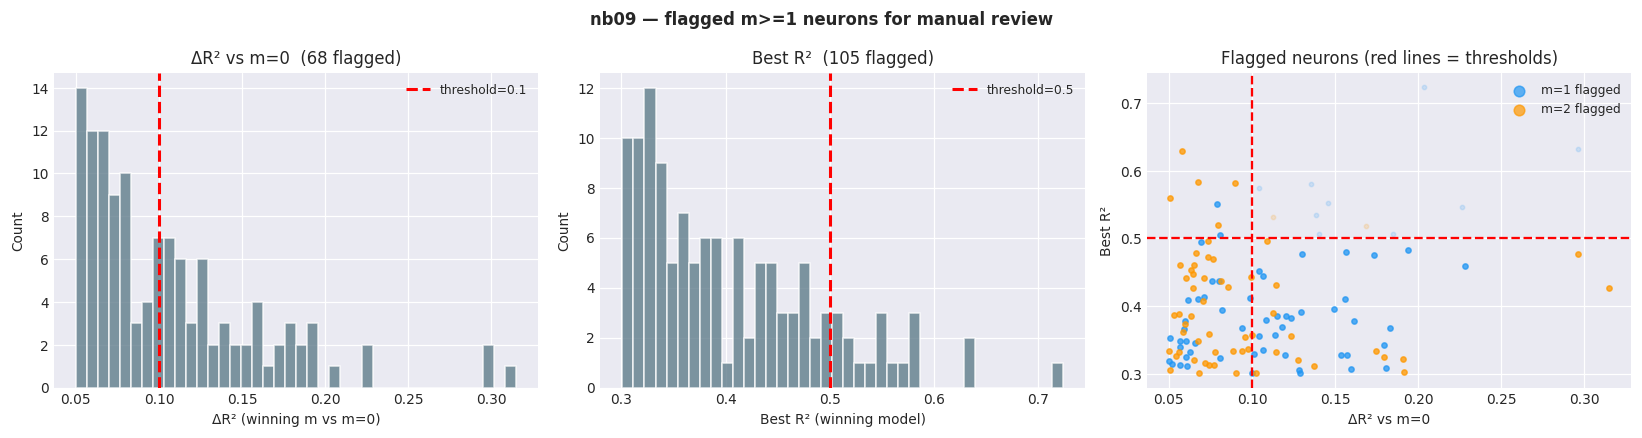

In [7]:
# ---------------------------------------------------------------------------
# Visualise flag distribution (m>=1 only)
# ---------------------------------------------------------------------------
ORDER_COLORS = {0: '#4CAF50', 1: '#2196F3', 2: '#FF9800'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('nb09 — flagged m>=1 neurons for manual review', fontweight='bold')

# delta_r2_vs_m0 distribution
ax = axes[0]
ax.hist(m1m2_df['delta_r2_vs_m0'].clip(-0.1, 0.6), bins=40,
        color='#607D8B', alpha=0.8, edgecolor='white')
ax.axvline(DELTA_R2_REVIEW_THRESHOLD, color='red', lw=2, ls='--',
           label=f'threshold={DELTA_R2_REVIEW_THRESHOLD}')
ax.set_xlabel('ΔR² (winning m vs m=0)')
ax.set_ylabel('Count')
ax.set_title(f'ΔR² vs m=0  ({n_marginal} flagged)')
ax.legend(fontsize=8)

# Best R² distribution
ax = axes[1]
ax.hist(m1m2_df['r_squared'], bins=40, color='#607D8B', alpha=0.8, edgecolor='white')
ax.axvline(R2_MIN_THRESHOLD, color='red', lw=2, ls='--',
           label=f'threshold={R2_MIN_THRESHOLD}')
ax.set_xlabel('Best R² (winning model)')
ax.set_ylabel('Count')
ax.set_title(f'Best R²  ({n_low_r2} flagged)')
ax.legend(fontsize=8)

# Scatter: delta_r2 vs best R², coloured by order
ax = axes[2]
for m in [1, 2]:
    sub_all  = m1m2_df[m1m2_df['derivative_order'] == m]
    sub_flag = flagged[flagged['derivative_order'] == m]
    ax.scatter(sub_all['delta_r2_vs_m0'].clip(-0.1, 0.6), sub_all['r_squared'],
               c=ORDER_COLORS[m], alpha=0.15, s=8)
    ax.scatter(sub_flag['delta_r2_vs_m0'].clip(-0.1, 0.6), sub_flag['r_squared'],
               c=ORDER_COLORS[m], alpha=0.7, s=12, label=f'm={m} flagged')
ax.axvline(DELTA_R2_REVIEW_THRESHOLD, color='red', lw=1.5, ls='--')
ax.axhline(R2_MIN_THRESHOLD,          color='red', lw=1.5, ls='--')
ax.set_xlabel('ΔR² vs m=0')
ax.set_ylabel('Best R²')
ax.set_title('Flagged neurons (red lines = thresholds)')
ax.legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig(nb09_dir / 'fig_nb09_flag_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# PART C — Manual review setup
# Pre-load RF maps for all flagged neurons
# ---------------------------------------------------------------------------
_MODEL_FNS = {0: gaussian_deriv_m0, 1: gaussian_deriv_m1, 2: gaussian_deriv_m2}
SMOOTH_SIGMA = 0.75

rf_map_cache  = {}
dataset_cache = {}
failed_containers = []

by_container = flagged.groupby('container_id')['cell_id'].apply(list)
t0 = time.time()

for container_id, cids in by_container.items():
    if container_id not in container_to_exp:
        print(f'  [SKIP] {container_id}: not in session_c')
        continue
    exp_id = container_to_exp[container_id]
    try:
        if container_id not in dataset_cache:
            dataset_cache[container_id] = boc.get_ophys_experiment_data(exp_id)
        maps = batch_get_rf_maps_safe(dataset_cache[container_id], cids)
        rf_map_cache.update(maps)
        print(f'  Container {container_id}: {len(maps)}/{len(cids)} maps')
    except Exception as e:
        failed_containers.append(container_id)
        print(f'  [FAIL] {container_id}: {e}')

print(f'\nRF maps cached: {len(rf_map_cache)}')
print(f'Failed containers: {failed_containers}')
print(f'Elapsed: {(time.time()-t0)/60:.1f} min')

  Container 511507650: 4/4 maps


In [ ]:
# ---------------------------------------------------------------------------
# Review helpers — refit + plot
# ---------------------------------------------------------------------------
def refit_all_orders(rf_map, pix_size, seed=None):
    """Re-fit m=0,1,2 with multi-start. Returns {m: (params, quality, fitted_map)}."""
    rf_on  = np.maximum(rf_map,  0.0)
    rf_off = np.maximum(-rf_map, 0.0)
    grid_h, grid_w = rf_map.shape
    Y, X = np.mgrid[0:grid_h, 0:grid_w].astype(float)
    xy   = (X, Y)
    rng  = np.random.default_rng(seed)

    results = {}
    for m in [0, 1, 2]:
        child_seed = int(rng.integers(0, 2**31))
        try:
            p, q = fit_rf_by_order(
                rf_on, rf_off, m=m,
                pixel_size_deg=pix_size,
                smooth_sigma=SMOOTH_SIGMA,
                n_random_starts=N_RANDOM_STARTS,
                seed=child_seed,
            )
            su_px = p['sigma_x'] / pix_size
            sv_px = p['sigma_y'] / pix_size
            x0_px = p['x0']     / pix_size
            y0_px = p['y0']     / pix_size
            th_r  = np.deg2rad(p['theta'])
            popt  = [p['amplitude'], x0_px, y0_px, su_px, sv_px, th_r, 0.0]
            fitted = _MODEL_FNS[m](xy, *popt).reshape(grid_h, grid_w)
            results[m] = (p, q, fitted)
        except Exception as e:
            results[m] = (None, {'r_squared': np.nan, 'message': str(e)}, None)
    return results


def plot_neuron_review(cid, rf_map, fit_results, auto_m, pix, row_info):
    r2s   = {m: fit_results[m][1]['r_squared'] for m in [0,1,2]}
    r2_m0 = r2s[0] if not np.isnan(r2s[0]) else 0.0

    refit_best = max([0,1,2], key=lambda m: r2s[m] if not np.isnan(r2s[m]) else -np.inf)
    if refit_best != 0 and (r2s[refit_best] - r2_m0 < DELTA_R2_THRESHOLD):
        refit_best = 0

    cre   = str(row_info.get('cre_line', ''))[:22]
    depth = row_info.get('depth_um', '')
    flags = []
    if row_info.get('flag_marginal_win'): flags.append(f'ΔR²={row_info.get("delta_r2_vs_m0",0):.3f}<0.10')
    if row_info.get('flag_low_r2'):       flags.append(f'R²={row_info["r_squared"]:.3f}<0.50')
    flag_str = '  ⚑ ' + '  '.join(flags) if flags else ''

    fig = plt.figure(figsize=(18, 4.2))
    gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.04)
    fig.suptitle(
        f'Cell {cid}  |  container {row_info.get("container_id","")}  '
        f'|  {cre}  {depth}μm  |  '
        f'auto m*={auto_m}  R²={row_info.get("r_squared",0):.3f}  '
        f'refit m*={refit_best}  '
        f'ΔR²(m1-m0)={r2s[1]-r2_m0:+.3f}  ΔR²(m2-m0)={r2s[2]-r2_m0:+.3f}'
        f'{flag_str}',
        fontsize=8.5, fontweight='bold'
    )

    vmax = np.nanpercentile(np.abs(rf_map), 98)
    imkw = dict(cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                aspect='auto', origin='lower', interpolation='nearest')

    panels = [('Raw RF', rf_map)] + [(f'm={m}', fit_results[m][2]) for m in [0,1,2]]
    for col, (title, img) in enumerate(panels):
        ax = fig.add_subplot(gs[0, col])
        if img is not None:
            ax.imshow(img, **imkw)
        else:
            ax.set_facecolor('#222')
            ax.text(0.5, 0.5, 'failed', color='w',
                    ha='center', va='center', transform=ax.transAxes)
        if col > 0:
            m = col - 1
            r2 = r2s[m]
            imp = (fit_results[m][0] or {}).get('r2_improvement', 0)
            parts = [f'R²={r2:.3f}']
            if m == refit_best: parts.append('★ best')
            if m == auto_m:     parts.append('▲ nb09')
            if imp > 0.05:      parts.append(f'⚠ +{imp:.2f}')
            title = f'm={m}\n' + '  '.join(parts)
        bold  = col > 0 and col - 1 == refit_best
        ax.set_title(title, fontsize=8,
                     fontweight='bold' if bold else 'normal',
                     color='#e67e22' if bold else 'black')
        ax.axis('off')
    return fig


print('Review helpers defined')

In [ ]:
# ---------------------------------------------------------------------------
# Load or initialise judgement store
# ---------------------------------------------------------------------------
inspectable = flagged[flagged['cell_id'].isin(rf_map_cache)].reset_index(drop=True)

if JUDGEMENT_CSV.exists():
    judged_df  = pd.read_csv(JUDGEMENT_CSV)
    judged_ids = set(judged_df['cell_id'].tolist())
    print(f'Loaded {len(judged_df)} existing judgements')
else:
    judged_df  = pd.DataFrame(columns=['cell_id','m_manual','note','flagged'])
    judged_ids = set()
    print('Starting fresh')

def _first_unjudged(start=0):
    for i in range(start, len(inspectable)):
        if inspectable.iloc[i]['cell_id'] not in judged_ids:
            return i
    return len(inspectable) - 1

if 'CURRENT_IDX' not in dir():
    CURRENT_IDX = _first_unjudged()

print(f'Inspectable: {len(inspectable)}')
print(f'Already judged: {len(judged_ids)}')
print(f'Remaining: {len(inspectable)-len(judged_ids)}')
print(f'Starting at index: {CURRENT_IDX}')

In [ ]:
# ---------------------------------------------------------------------------
# CELL 11 — Show neuron   (re-run to view current neuron)
# Set CURRENT_IDX = N before running to jump to a specific neuron
# ---------------------------------------------------------------------------
row     = inspectable.iloc[CURRENT_IDX]
cid     = int(row['cell_id'])
rf_map, pix = rf_map_cache[cid]
auto_m  = int(row['derivative_order'])

done  = len(judged_ids)
total = len(inspectable)
print(f'--- Neuron {CURRENT_IDX+1}/{total}  ({done} judged, {total-done} remaining) ---')
print(f'cell_id={cid}  container={row["container_id"]}  '
      f'{row["cre_line"]}  {row["depth_um"]}μm')
print(f'nb09 auto m*={auto_m}  R²={row["r_squared"]:.3f}  '
      f'ΔR²vs_m0={row["delta_r2_vs_m0"]:.3f}')
flags = []
if row.get('flag_marginal_win'): flags.append(f'MARGINAL WIN (ΔR²={row["delta_r2_vs_m0"]:.3f}<0.10)')
if row.get('flag_low_r2'):       flags.append(f'LOW R² ({row["r_squared"]:.3f}<0.50)')
if flags: print(f'Flags: {" + ".join(flags)}')
if cid in judged_ids:
    prev = judged_df[judged_df['cell_id']==cid].iloc[-1]
    print(f'↩  Already judged: m={prev["m_manual"]}  note="{prev["note"]}"  flag={prev["flagged"]}')

_fit_cache = refit_all_orders(rf_map, pix, seed=cid)
r2s = {m: _fit_cache[m][1]['r_squared'] for m in [0,1,2]}
r2_m0 = r2s[0] if not np.isnan(r2s[0]) else 0.0
_refit_best = max([0,1,2], key=lambda m: r2s[m] if not np.isnan(r2s[m]) else -np.inf)
if _refit_best != 0 and (r2s[_refit_best] - r2_m0 < DELTA_R2_THRESHOLD):
    _refit_best = 0

for m in [0,1,2]:
    p   = _fit_cache[m][0]
    imp = p.get('r2_improvement', 0) if p else 0
    lm  = ' ⚠ local-min rescued' if imp > 0.05 else ''
    print(f'  m={m}  R²={r2s[m]:.3f}{lm}')
print(f'Suggested: m={_refit_best}  '
      f'(ΔR²(m1-m0)={r2s[1]-r2_m0:+.3f}  ΔR²(m2-m0)={r2s[2]-r2_m0:+.3f})')

fig = plot_neuron_review(cid, rf_map, _fit_cache, auto_m, pix, row.to_dict())
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# CELL 12 — Record judgement, then re-run Cell 11 for next neuron
#
# M_ACCEPT: 0, 1, 2 to accept that order; -1 to skip (keep auto)
# NOTE:     free text
# FLAG:     True to mark for second-pass
# ---------------------------------------------------------------------------
M_ACCEPT = 0   # ← change if you disagree
NOTE     = ''            # ← optional
FLAG     = False         # ← True to flag

row = inspectable.iloc[CURRENT_IDX]
cid = int(row['cell_id'])

new_row   = pd.DataFrame([{'cell_id': cid, 'm_manual': M_ACCEPT,
                            'note': NOTE, 'flagged': FLAG}])
judged_df  = pd.concat([judged_df[judged_df['cell_id'] != cid], new_row],
                        ignore_index=True)
judged_ids = set(judged_df['cell_id'].tolist())
judged_df.to_csv(JUDGEMENT_CSV, index=False)

done = len(judged_ids)
print(f'✓ Saved  cell {cid}  m={M_ACCEPT}  '
      f'({done}/{len(inspectable)} done, {len(inspectable)-done} remaining)')

CURRENT_IDX = _first_unjudged(CURRENT_IDX + 1)
print(f'Next: index {CURRENT_IDX}  →  re-run Cell 11')

In [ ]:
# ---------------------------------------------------------------------------
# Review progress summary  (run any time)
# ---------------------------------------------------------------------------
if JUDGEMENT_CSV.exists():
    judged_df = pd.read_csv(JUDGEMENT_CSV)

done  = len(judged_df)
total = len(inspectable)
print(f'Progress: {done}/{total} ({100*done/total:.0f}%)')
print()
print('Manual m distribution (including skips=-1):')
print(judged_df['m_manual'].value_counts().sort_index()
      .rename({-1:'Skip'}))
print()

judged_non_skip = judged_df[judged_df['m_manual'] >= 0]
merged = inspectable.merge(judged_non_skip, on='cell_id', how='inner')
if len(merged):
    agree = (merged['derivative_order'] == merged['m_manual']).mean()
    print(f'Auto / manual agreement: {agree:.1%}  (n={len(merged)})')
    print()
    print('Crosstab (rows=auto, cols=manual):')
    print(pd.crosstab(merged['derivative_order'], merged['m_manual'],
                      rownames=['auto'], colnames=['manual']))

In [ ]:
# ---------------------------------------------------------------------------
# PART D — Merge and save final population CSV
#
# m_final rules:
#   Judged and accepted (m_manual >= 0): use m_manual
#   Skipped (m_manual == -1):            keep nb09 derivative_order
#   Not flagged / not reviewed:          keep nb09 derivative_order
# ---------------------------------------------------------------------------
judged_df = pd.read_csv(JUDGEMENT_CSV)

final_df = all_df.merge(
    judged_df[['cell_id','m_manual','note','flagged']],
    on='cell_id', how='left'
)

final_df['m_final'] = np.where(
    final_df['m_manual'].notna() & (final_df['m_manual'] >= 0),
    final_df['m_manual'].astype('Int64'),
    final_df['derivative_order']
).astype(int)

final_df.to_csv(FINAL_CSV, index=False)

print(f'Saved {len(final_df):,} neurons → {FINAL_CSV}')
print()
print('m_final breakdown:')
print(final_df['m_final'].value_counts().sort_index())
print()

m0   = final_df[final_df['m_final'] == 0]
m1   = final_df[final_df['m_final'] == 1]
m2   = final_df[final_df['m_final'] == 2]
m1m2 = final_df[final_df['m_final'].isin([1,2])]

print(f'm=0: {len(m0)}   m=1: {len(m1)}   m=2: {len(m2)}   m>=1: {len(m1m2)}')
print()
print('σ, κ for m>=1 (final):')
print(m1m2[['sigma','kappa','r_squared']].describe().round(3))

In [ ]:
# ---------------------------------------------------------------------------
# Parameter overview — final population
# ---------------------------------------------------------------------------
ORDER_COLORS = {0: '#4CAF50', 1: '#2196F3', 2: '#FF9800'}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('nb09 — final manually-reviewed population', fontsize=12, fontweight='bold')

# Order breakdown pie
ax = axes[0, 0]
counts = final_df['m_final'].value_counts().sort_index()
ax.pie(counts.values,
       labels=[f'm={m}\n({c}, {100*c/len(final_df):.0f}%)' for m, c in counts.items()],
       colors=[ORDER_COLORS[m] for m in counts.index],
       startangle=90, textprops={'fontsize': 9})
ax.set_title('Order breakdown')

# σ distributions
for col_i, (m_sel, label) in enumerate([(1,'m=1'),(2,'m=2'),(None,'m>=1')], start=1):
    ax  = axes[0, col_i]
    sub = m1m2 if m_sel is None else final_df[final_df['m_final']==m_sel]
    col = '#9C27B0' if m_sel is None else ORDER_COLORS[m_sel]
    ax.hist(sub['sigma'].dropna(), bins=25, color=col, alpha=0.75, edgecolor='white')
    ax.set_xlabel('σ (degrees)')
    ax.set_title(f'{label}  σ  (n={len(sub)})')

# κ distributions
for col_i, (m_sel, label) in enumerate([(1,'m=1'),(2,'m=2'),(None,'m>=1')], start=1):
    ax  = axes[1, col_i]
    sub = m1m2 if m_sel is None else final_df[final_df['m_final']==m_sel]
    col = '#9C27B0' if m_sel is None else ORDER_COLORS[m_sel]
    ax.hist(sub['kappa'].dropna(), bins=25, color=col, alpha=0.75, edgecolor='white')
    ax.set_xlabel('κ (elongation)')
    ax.set_title(f'{label}  κ')

# σ-κ coupling for m>=1
ax = axes[1, 0]
for m in [1, 2]:
    sub = final_df[final_df['m_final'] == m]
    ax.scatter(sub['sigma'], sub['kappa'],
               c=ORDER_COLORS[m], alpha=0.3, s=8, label=f'm={m}')
ax.set_xlabel('σ (degrees)')
ax.set_ylabel('κ')
ax.set_title('σ-κ coupling  m>=1')
ax.legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig(nb09_dir / 'fig_nb09_final_population.png', dpi=150, bbox_inches='tight')
plt.show()

# σ-κ Pearson r
from scipy.stats import pearsonr
r, p = pearsonr(m1m2['sigma'].dropna(), m1m2['kappa'].dropna())
print(f'σ-κ Pearson r = {r:.3f}  p = {p:.2e}  (m>=1, n={len(m1m2)})')